# **PROYEK ANALISA SENTIMEN MULTICLASS**

---

Analisa sentimen reviewer aplikasi bima+ dari Google Play Store menggunakan tiga metode berbeda dengan **3 Label Kelas**:
- 🟢 **Positif**
- 🟡 **Netral**  
- 🔴 **Negatif**

# Import Library

In [ ]:
!pip install sastrawi
!pip install nltk
# !pip install google-play-scraper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.2 MB/s eta 0:00:00


In [ ]:
 # Data Manipulasi
import pandas as pd
import numpy as np
import csv
import requests
from io import StringIO

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Pra-processing text
import re
import string
import datetime as dt
from nltk import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional,
    Conv1D, MaxPooling1D, GRU, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("Semua library berhasil diimport!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Semua library berhasil diimport!


# Preprocessing Text

In [ ]:
df = pd.read_csv('.../dataset/ulasan_aplikasi.csv')
print(f"Jumlah ulasan: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

Jumlah ulasan: 446645
Jumlah kolom: 11


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,248f457f-5a00-4294-a481-16ac60ebeb42,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bima+, perlu penambahan link sms masuk, fungsi...",5,1,5.14.0,2026-05-11 14:54:20,"Hi Kak, terima kasih atas saran dan masukan ya...",2026-05-12 02:26:12,5.14.0
1,20a32fbc-29f4-47be-b50a-c8770635da4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah mahal udah beli kuota nya lama ga masuk m...,1,1,5.14.0,2026-05-12 07:50:12,"Hai Kak, maaf ya. Terkait harga paket mengalam...",2025-12-06 12:21:54,5.14.0
2,3c7badbe-edea-413c-828a-273df729cbcd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk keseluruhan sudah bagus, hanya saja ada ...",4,0,5.14.0,2026-05-13 08:51:01,"Hi Kak, terima kasih atas saran yang diberikan...",2026-05-13 09:16:51,5.14.0
3,8611af61-ef74-4728-a16f-4d0783d70dfe,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi Bima+ mulai ngga jelas, saya beli pak...",3,7,5.13.0,2026-04-30 03:09:25,"Hai Kak Ajja, makasih ya sudah hubungi Tri 😊\n...",2026-04-27 00:41:58,5.13.0
4,83740a24-12d2-4dce-9dc6-f1d2c5623736,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bagus, memudahkan tapi ya kalau paket data uda...",4,2,5.14.0,2026-05-10 02:38:57,"Hi Kak Anggun, mohon maaf ya. Pastikan saat ak...",2026-05-11 00:46:34,5.14.0


In [ ]:
# Hapus baris kosong dan duplikat
clean_df = df.dropna(subset=['content'])
clean_df = clean_df.drop_duplicates(subset=['content'])
clean_df = clean_df.reset_index(drop=True)

print(f"Jumlah ulasan setelah cleaning: {clean_df.shape[0]}")

Jumlah ulasan setelah cleaning: 312510


In [ ]:
# ── Kamus Slangwords ──────────────────────────────────────────────────────────
slangwords = {
    "gak": "tidak", "gk": "tidak", "ga": "tidak", "g": "tidak","bagu":"bagus",
    "bgt": "banget", "bgttt": "banget", "bgtt": "banget",
    "yg": "yang", "sy": "saya", "ak": "saya", "aq": "saya",
    "gw": "saya", "gua": "saya", "lo": "kamu", "lu": "kamu",
    "kalo": "kalau", "kl": "kalau", "klw": "kalau",
    "udah": "sudah", "ud": "sudah", "sdh": "sudah",
    "blm": "belum", "blum": "belum", "lum": "belum",
    "tp": "tapi", "tpi": "tapi", "pi": "tapi",
    "jg": "juga", "jga": "juga", "dgn": "dengan",
    "bs": "bisa", "bsa": "bisa", "krn": "karena", "karna": "karena",
    "utk": "untuk", "u": "kamu", "nih": "ini", "ni": "ini",
    "makasih": "terima kasih", "thx": "terima kasih", "tq": "terima kasih",
    "aja": "saja", "aj": "saja", "sj": "saja",
    "nggak": "tidak", "ngga": "tidak", "enggak": "tidak",
    "gimana": "bagaimana", "gmana": "bagaimana",
    "bener": "benar", "bnr": "benar","ngelag":"lag", "hang":"lag",
    "banget": "sangat", "bgt": "sangat","lelet":"lambat",
    "lama": "lama", "lelet": "lambat", "lemot": "lambat",
    "mati": "error", "hang": "error", "eror": "error",
    "bagus": "bagus", "mantap": "bagus", "keren": "bagus",
    "jelek": "buruk", "parah": "buruk", "payah": "buruk","lemottt":"lambat",
    "oke": "ok", "otw": "segera", "asap": "segera","lgi":"lagi","apk":"aplikasi",
    "abis":"habis", "voucer":"voucher", "bener":"benar","capek":"lelah", "nyesel":"kecewa",
    "gabisa":"tidak bisa"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords.get(word.lower(), word) for word in words]
    return ' '.join(fixed_words)

In [ ]:
# ── Fungsi-fungsi Preprocessing ────────────────────────────────────────────────

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)   # hapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text)   # hapus hashtag
    text = re.sub(r'RT[\s]', '', text)           # hapus RT
    text = re.sub(r'http\S+', '', text)          # hapus link
    text = re.sub(r'[0-9]+', '', text)           # hapus angka
    text = re.sub(r'[^\w\s]', '', text)          # hapus karakter khusus
    text = text.replace('\n', ' ')              # ganti newline
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

def casefoldingText(text):
    return text.lower()

def tokenizingText(text):
    return word_tokenize(text)

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords.update(set(stopwords.words('english')))
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',
                          'di','ga','ya','gaa','loh','kah','woi', "tri",
                          "tolong", "masuk", "udh","pake", "doang", "tru", "min",
                          "cb", "sm", "three", "coba", "kubu","pa", "gua", "gue",
                          "aku", "jiwa"
                          ])
    return [word for word in text if word not in listStopwords]

def stemmingText(text): # Lemmatization atau Stemming gk dipakai
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

def toSentence(list_words):
    return ' '.join(word for word in list_words)

In [ ]:
# ── Jalankan Pipeline Preprocessing ───────────────────────────────────────────
print("Memulai preprocessing...")

clean_df['text_clean']         = clean_df['content'].apply(cleaningText)
clean_df['text_casefold']      = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords']    = clean_df['text_casefold'].apply(fix_slangwords)
clean_df['text_tokenize']      = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword']      = clean_df['text_tokenize'].apply(filteringText)
clean_df['text_akhir']         = clean_df['text_stopword'].apply(toSentence)

print("Preprocessing selesai!")
clean_df[['content', 'text_akhir']].head(5)

Memulai preprocessing...
Preprocessing selesai!


,content,text_akhir
0,"bima+, perlu penambahan link sms masuk, fungsi...",bima penambahan link sms fungsinya sms pesan s...
1,udah mahal udah beli kuota nya lama ga masuk m...,mahal beli kuota nunggu menitan info paket bel...
2,"Untuk keseluruhan sudah bagus, hanya saja ada ...",bagus keluhan fitur penghitungan batas sisa ku...
3,"Aplikasi Bima+ mulai ngga jelas, saya beli pak...",aplikasi bima beli paket bayar saldo berkurang...
4,"bagus, memudahkan tapi ya kalau paket data uda...",bagus memudahkan paket data habis membeli apli...


# Pelabelan Multiclass (Positif / Netral / Negatif)

**Aturan penilaian skor lexicon:**
- Skor **> 0** → label **positif**
- Skor **= 0** → label **netral**
- Skor **< 0** → label **negatif**

In [ ]:
# ── Load Lexicon ───────────────────────────────────────────────────────────────
lexicon_positive = set(["lancar", "bagus","mudah", "cepat", "jelas", "potongan harga", "baik", "murah hati",
                        "poin", "voucher", "belanja", "tidak lag", "tidak ngelag", "tegas", "benar", 'senang',
                        "aman", "maju", "percaya", "dipercaya", "bervariasi", "tidak curang","stabil", "aman",
                        "responsif", "efisien", "praktis", "mudah", "fleksibel", "ringan", "terpercaya", "modern",
                        "inovatif", "hemat", "interaktif", "terstruktur","multifungsi", "ramah", "berkualitas", "lancar",
                        "optimal","andal", "canggih", "adaptif", "dinamis", "akurat", "murah", "promo", "lumayan", "masih", "sudah lumayan"
                      ])
response = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
print(f"Lexicon positif dimuat: {len(lexicon_positive)} kata")


lexicon_negative = set(["lag", "kecewa", "lambat", "beli", "mahal", "buruk", "tidak jelas", "sangat buruk", "tidak bisa dipakai",
                        "keluhan", "lenyap", "sia-sia", "sia sia", "tidak bisa dibuka", "aneh", "lama sekali", "dipersulit",
                        "tidak jelas", "bug", "lama", "gagal", "merugikan", "rugi", "mengecewakan", "kesal", "rusak", "kerusakan",
                        "tidak bisa", "nggak bisa", "jelek", "permasalahan", "kendala", "mahal", "habis", "kurang percaya", "tidak bisa digunakan",
                        "error", "percuma", "tidak masuk", "agak lain", "gimmick", "gangguan", "lelah", "curang", "gabecus", "gausah beli", "najis", "tidak sinkron",
                        "jaringan buruk", "jaringan sangat buruk", "tidak rekomended", "ga bisa dibuka",
                        ])
test = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'
print(f"Lexicon negatif dimuat: {len(lexicon_negative)} kata")

Lexicon positif dimuat: 48 kata
Lexicon negatif dimuat: 50 kata


In [ ]:
# ── Fungsi Pelabelan Multiclass ────────────────────────────────────────────────

def sentiment_multiclass(text):
    """
    Menghitung skor sentimen berdasarkan lexicon.
    Returns:
        polarity (str): 'positif', 'netral', atau 'negatif'
    """
    # Cek kata negatif
    for word in lexicon_negative: # Corrected: Check negative lexicon for negative words
        if re.search(r'\b' + re.escape(word) + r'\b', text):
            return "negatif"

    # Cek kata positif
    for word in lexicon_positive: # Corrected: Check positive lexicon for positive words
        if re.search(r'\b' + re.escape(word) + r'\b', text):
            return "positif"

    return "netral"


# Terapkan fungsi ke dataframe
results = clean_df['text_akhir'].apply(sentiment_multiclass) # Corrected: Apply to 'text_akhir' which is a string
clean_df['sentiment'] = results # Assign results to a new 'sentiment' column

print("Distribusi label sentimen:")
print(clean_df['sentiment'].value_counts())

Distribusi label sentimen:
sentiment
netral     148785
negatif    114652
positif     49073
Name: count, dtype: int64


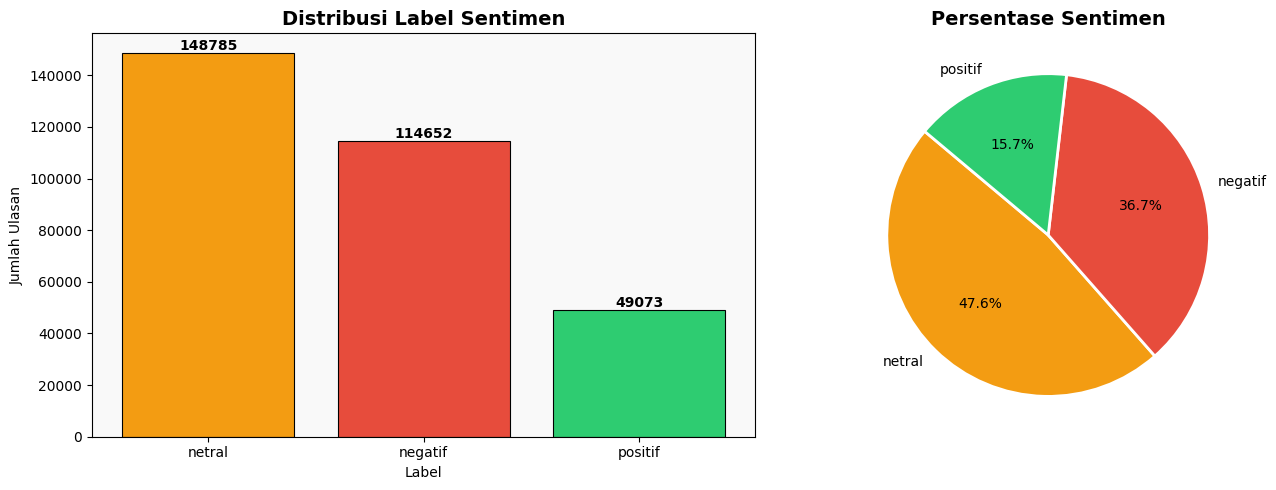

In [ ]:
# ── Visualisasi Distribusi Label ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'positif': '#2ecc71', 'netral': '#f39c12', 'negatif': '#e74c3c'}
label_counts = clean_df['sentiment'].value_counts()
bars = axes[0].bar(label_counts.index,
                   label_counts.values,
                   color=[colors.get(l, 'gray') for l in label_counts.index],
                   edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontweight='bold')

axes[0].set_title('Distribusi Label Sentimen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].set_facecolor('#f9f9f9')

# Pie chart
pie_colors = [colors.get(l, 'gray') for l in label_counts.index]
axes[1].pie(label_counts.values,
            labels=label_counts.index,
            autopct='%1.1f%%',
            colors=pie_colors,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Persentase Sentimen', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2575/835344383.py:25: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2575/835344383.py:25: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2575/835344383.py:25: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2575/835344383.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2575/835344383.py:26: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2575/835344383.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight

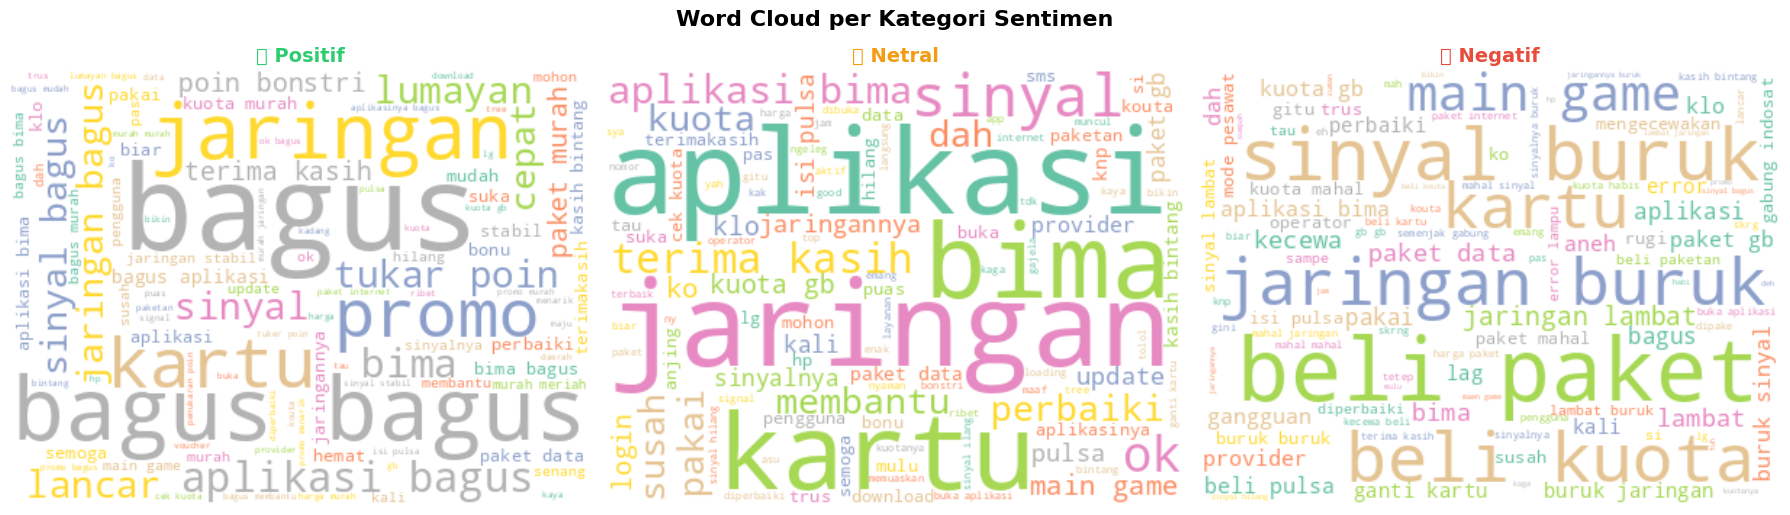

In [ ]:
# ── Word Cloud per Kategori ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
title_map = {'positif': ('🟢 Positif', '#2ecc71'),
             'netral':  ('🟡 Netral',  '#f39c12'),
             'negatif': ('🔴 Negatif', '#e74c3c')}

for ax, label in zip(axes, ['positif', 'netral', 'negatif']):
    subset = clean_df[clean_df['sentiment'] == label]['text_akhir']
    all_text = ' '.join(subset.dropna())

    if len(all_text.strip()) == 0:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center')
    else:
        wc = WordCloud(width=400, height=300,
                       background_color='white',
                       colormap='Set2',
                       max_words=100).generate(all_text)
        ax.imshow(wc, interpolation='bilinear')

    title, color = title_map[label]
    ax.set_title(title, fontsize=14, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle('Word Cloud per Kategori Sentimen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

[('jaringan', 53392), ('sinyal', 48234), ('kuota', 42870), ('paket', 42170), ('buruk', 41758), ('aplikasi', 35570), ('bagus', 33665), ('beli', 29345), ('gb', 28653), ('kartu', 28552), ('bima', 27258), ('pulsa', 25331), ('lambat', 24383), ('mahal', 15720), ('kecewa', 15460), ('perbaiki', 13399), ('hilang', 12625), ('murah', 12268), ('game', 11725), ('kasih', 11707)]


/tmp/ipykernel_2575/3997189458.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


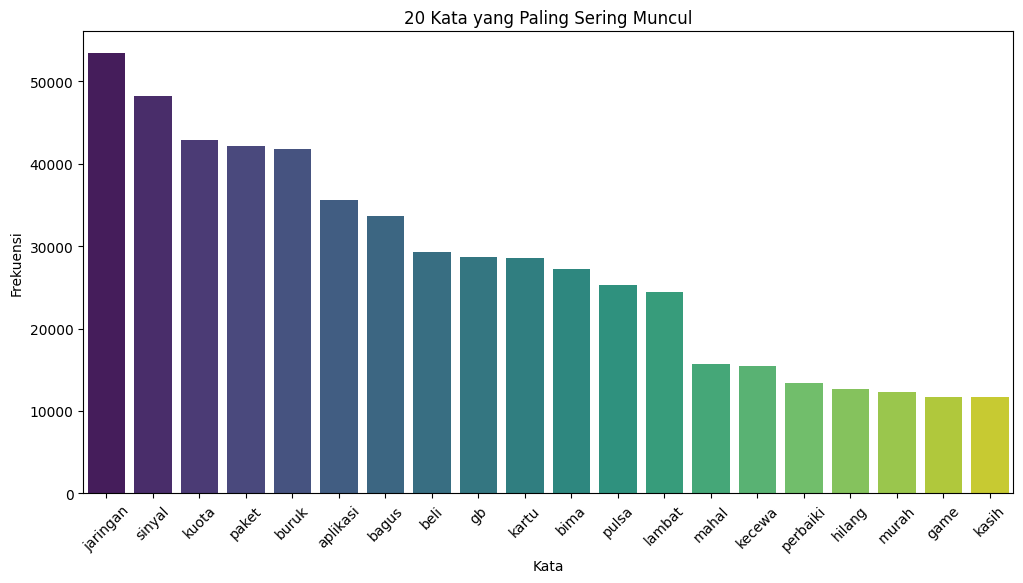

In [ ]:
from collections import Counter
# Gabungkan semua teks
all_words = " ".join(clean_df["text_akhir"]).split()

# Hitung frekuensi kata
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)  # Ambil 20 kata paling sering

# Pisahkan kata dan jumlah kemunculannya
words, counts = zip(*common_words)


print(common_words)
# Plot frekuensi kata
plt.figure(figsize=(12,6))
sns.barplot(x=list(words), y=list(counts), palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title("20 Kata yang Paling Sering Muncul")
plt.show()

# Pemodelan 3 Model Multiclass

In [ ]:
# ── Konfigurasi Parameter ──────────────────────────────────────────────────────
MAX_VOCAB  = 10000   # Ukuran kosakata maksimum
MAX_LEN    = 100     # Panjang maksimum setiap teks (padding)
EMBED_DIM  = 128     # Dimensi embedding
LSTM_UNITS = 64      # Jumlah unit LSTM
DROPOUT    = 0.3     # Dropout rate
BATCH_SIZE = 256       # 128 atau 256
EPOCHS     = 50      # -> 50 atau 100
NUM_CLASSES = 3      # positif, netral, negatif

print(f"Konfigurasi model:")
print(f"  Vocab size  : {MAX_VOCAB}")
print(f"  Max length  : {MAX_LEN}")
print(f"  Embed dim   : {EMBED_DIM}")
print(f"  LSTM units  : {LSTM_UNITS}")
print(f"  Num classes : {NUM_CLASSES}")

Konfigurasi model:
  Vocab size  : 10000
  Max length  : 100
  Embed dim   : 128
  LSTM units  : 64
  Num classes : 3


In [ ]:
# ── Encoding Label ─────────────────────────────────────────────────────────────
# Encode label string → integer: negatif=0, netral=1, positif=2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(clean_df['sentiment'])

print("Mapping label:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} → {cls}")

# One-hot encoding untuk categorical_crossentropy
y_onehot = to_categorical(y_encoded, num_classes=NUM_CLASSES)
print(f"\nBentuk y_onehot: {y_onehot.shape}")

Mapping label:
  0 → negatif
  1 → netral
  2 → positif

Bentuk y_onehot: (312510, 3)


In [ ]:
# ── Tokenisasi & Padding ───────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(clean_df['text_akhir'].fillna(''))

X_sequences = tokenizer.texts_to_sequences(clean_df['text_akhir'].fillna(''))
X_padded    = pad_sequences(X_sequences, maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"Ukuran kosakata: {len(tokenizer.word_index)}")
print(f"Bentuk data setelah padding: {X_padded.shape}")

Ukuran kosakata: 129201
Bentuk data setelah padding: (312510, 100)


In [ ]:
# ── Split Data Train / Validation / Test ───────────────────────────────────────
# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y_onehot, test_size=0.30, random_state=42, stratify=y_encoded)

# Split y_encoded yang sesuai untuk stratify di split kedua
_, y_temp_encoded = train_test_split(
    y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp_encoded)

print(f"Data train      : {X_train.shape[0]} sampel")
print(f"Data validasi   : {X_val.shape[0]} sampel")
print(f"Data test       : {X_test.shape[0]} sampel")

Data train      : 218757 sampel
Data validasi   : 46876 sampel
Data test       : 46877 sampel


## Model Bi  LSTM + Embedding Layers

In [ ]:
# ── Arsitektur Model LSTM Multiclass ───────────────────────────────────────────
tf.random.set_seed(42)

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

# Compile dengan categorical_crossentropy karena label one-hot
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',   # <-- multiclass
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Training ───────────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import Callback
# Callback untuk berhenti jika akurasi mencapai 95%
class StopAtAccuracy(Callback):
    def __init__(self, target_accuracy=0.85):
        super(StopAtAccuracy, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get("val_accuracy")
        if val_acc is not None and val_acc >= self.target_accuracy:
            print(f"\nStopping training as val_accuracy reached {val_acc:.4f} (≥ {self.target_accuracy})")
            self.model.stop_training = True

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[StopAtAccuracy()],
    verbose=1
)

Epoch 1/50
853/855 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9028 - loss: 0.2292
Stopping training as val_accuracy reached 0.9997 (≥ 0.85)
855/855 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9739 - loss: 0.0671 - val_accuracy: 0.9997 - val_loss: 0.0024


## Model Bi GRU (Gated Recurrent Unit) + Embedding Layers


In [ ]:
model_gru = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(GRU(
        units=LSTM_UNITS,
        return_sequences=False,
    )),
    Dense(256, activation='relu'),
    Dropout(DROPOUT),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile dengan categorical_crossentropy karena label one-hot
model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',   # <-- multiclass
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[StopAtAccuracy()],
    verbose=1
)

Epoch 1/50
853/855 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9249 - loss: 0.1744
Stopping training as val_accuracy reached 0.9996 (≥ 0.85)
855/855 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9812 - loss: 0.0471 - val_accuracy: 0.9996 - val_loss: 0.0024


## Model CNN + GlobalMaxPooling(TextCNN)Tokenizer

In [ ]:
model_cnn = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(DROPOUT),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile dengan categorical_crossentropy karena label one-hot
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',   # <-- multiclass
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[StopAtAccuracy()],
    verbose=1
)

Epoch 1/50
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9252 - loss: 0.1786
Stopping training as val_accuracy reached 0.9999 (≥ 0.85)
855/855 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9822 - loss: 0.0457 - val_accuracy: 0.9999 - val_loss: 0.0013


# Evaluasi Model

In [ ]:
# ── Evaluasi pada Data Test ────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("EVALUASI MODEL 1")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\nEVALUASI MODEL 2")
test_loss, test_acc = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\nEVALUASI MODEL 2")
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")


EVALUASI MODEL 1
Test Loss     : 0.0012
Test Accuracy : 0.9998 (99.98%)

EVALUASI MODEL 2
Test Loss     : 0.0028
Test Accuracy : 0.9997 (99.97%)

EVALUASI MODEL 2
Test Loss     : 0.0008
Test Accuracy : 0.9999 (99.99%)


In [ ]:
# ── Prediksi & Classification Report ──────────────────────────────────────────
# Ini untuk Model 1
y_pred_prob = model.predict(X_test)
y_pred_idx  = np.argmax(y_pred_prob, axis=1)
y_true_idx  = np.argmax(y_test, axis=1)
# Ini untuk model 2
y_pred_prob_gru = model_gru.predict(X_test)
y_pred_idx_gru  = np.argmax(y_pred_prob_gru, axis=1)
y_true_idx_gru  = np.argmax(y_test, axis=1)
# Ini untuk model 2
y_pred_prob_cnn = model_cnn.predict(X_test)
y_pred_idx_cnn  = np.argmax(y_pred_prob_cnn, axis=1)
y_true_idx_cnn  = np.argmax(y_test, axis=1)


target_names = label_encoder.classes_  # ['negatif', 'netral', 'positif']

print("Classification Report Model LSTM:")
print("="*55)
print(classification_report(y_true_idx, y_pred_idx,
                             target_names=target_names))

print("\nClassification Report Model GRU:")
print("="*55)
print(classification_report(y_true_idx_gru, y_pred_idx_gru,
                             target_names=target_names))

print("\nClassification Report Model CNN:")
print("="*55)
print(classification_report(y_true_idx_cnn, y_pred_idx_cnn,
                             target_names=target_names))

1465/1465 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Classification Report Model LSTM:
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00     17198
      netral       1.00      1.00      1.00     22318
     positif       1.00      1.00      1.00      7361

    accuracy                           1.00     46877
   macro avg       1.00      1.00      1.00     46877
weighted avg       1.00      1.00      1.00     46877


Classification Report Model GRU:
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00     17198
      netral       1.00      1.00      1.00     22318
     positif       1.00      1.00      1.00      7361

    accuracy                           1.00     46877
   macro avg       1.00      1.00      1.00     46877
weighted avg       1.00      1.00      1.00     46877


Classification Report Model CNN:
      

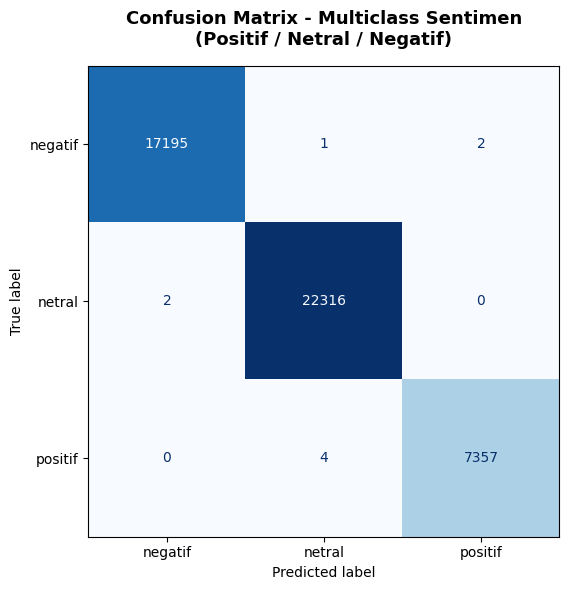

In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_true_idx, y_pred_idx)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix - Multiclass Sentimen\n(Positif / Netral / Negatif)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Prediksi Teks Baru

In [ ]:
# ── Fungsi Prediksi Ulasan Baru ────────────────────────────────────────────────

def predict_sentiment(text, model, tokenizer, label_encoder):
    """
    Menerima teks ulasan mentah, lakukan preprocessing,
    lalu prediksi sentimen (positif / netral / negatif).
    """
    # 1. Preprocessing
    text = cleaningText(text)
    text = casefoldingText(text)
    text = fix_slangwords(text)
    tokens = tokenizingText(text)
    tokens = filteringText(tokens)
    text_final = toSentence(tokens)

    # 2. Tokenisasi & Padding
    seq     = tokenizer.texts_to_sequences([text_final])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # 3. Prediksi
    probs   = model_cnn.predict(padded, verbose=0)[0]
    idx     = np.argmax(probs)
    label   = label_encoder.classes_[idx]

    # 4. Output
    emoji_map = {'positif': '🟢', 'netral': '🟡', 'negatif': '🔴'}
    print(f"Teks   : {text[:80]}..." if len(text) > 80 else f"Teks   : {text}")
    print(f"Hasil  : {emoji_map.get(label, '')} {label.upper()}")
    print(f"Skor   : negatif={probs[0]:.3f} | netral={probs[1]:.3f} | positif={probs[2]:.3f}")
    print("-" * 55)
    return label


# ── Contoh Penggunaan ──────────────────────────────────────────────────────────
contoh_ulasan = [
    "Aplikasinya bagus banget, fiturnya lengkap dan mudah digunakan!",
    "Biasa saja, tidak ada yang spesial dari aplikasi ini.",
    "Sangat mengecewakan, sering error dan loading lama sekali!",
    "Sebenarnya lumayan, tapi masih ada beberapa bug kecil.",
    "Mantap jiwa! Recommended banget buat yang butuh aplikasi ini.",
    "Kenapa ini aplikasinya gabisa dibuka!!",
    "aneh banget fiturnya ",
    "kok gabisa dibuka sihh??",
    "aku gatau kenapa gabisa dibuka, emang agak agak"
]

print("=" * 55)
print("  PREDIKSI SENTIMEN ULASAN BARU")
print("=" * 55)
for ulasan in contoh_ulasan:
    predict_sentiment(ulasan, model, tokenizer, label_encoder)

  PREDIKSI SENTIMEN ULASAN BARU
Teks   : aplikasinya bagus sangat fiturnya lengkap dan mudah digunakan
Hasil  : 🟢 POSITIF
Skor   : negatif=0.000 | netral=0.000 | positif=1.000
-------------------------------------------------------
Teks   : biasa saja tidak ada yang spesial dari aplikasi ini
Hasil  : 🟡 NETRAL
Skor   : negatif=0.000 | netral=1.000 | positif=0.000
-------------------------------------------------------
Teks   : sangat mengecewakan sering error dan loading lama sekali
Hasil  : 🔴 NEGATIF
Skor   : negatif=1.000 | netral=0.000 | positif=0.000
-------------------------------------------------------
Teks   : sebenarnya lumayan tapi masih ada beberapa bug kecil
Hasil  : 🔴 NEGATIF
Skor   : negatif=1.000 | netral=0.000 | positif=0.000
-------------------------------------------------------
Teks   : bagus jiwa recommended sangat buat yang butuh aplikasi ini
Hasil  : 🟢 POSITIF
Skor   : negatif=0.000 | netral=0.000 | positif=1.000
----------------------------------------------------

In [ ]:
# ── Simpan Model & Tokenizer ───────────────────────────────────────────────────
import pickle

model.save('model_sentimem_lstm.h5')
model_gru.save('model_sentimem_gru.h5')
model_cnn.save('model_sentimem_cnn.h5')

with open('tokenizer_multiclass.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder_multiclass.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

Model, tokenizer, dan label encoder berhasil disimpan!
  → model_sentimen_multiclass.keras
  → tokenizer_multiclass.pkl
  → label_encoder_multiclass.pkl
